# NB04 — Pangenome Accessory Contrast

**Project**: NEON metagenome lineage novelty and functional ecology

## Scientific motivation

Cultured genomes are a biased sample of microbial diversity. They tend to be (a) phylogenetically narrow (driven by the medical/biotech relevance of their hosts) and (b) ecologically narrow (axenic culture rarely demands the full accessory genome a microbe carries in its native habitat). The KBase KE pangenome catalog represents the **cultured, sequenced, GTDB-classified** view of microbial gene content: 27,690 species, 132 M gene clusters, with per-cluster core/accessory labels.

Environmental MAGs are different. They are reconstructed from a metagenome rather than streaked from a Petri plate, so they sample whatever genome a microbe happened to be carrying in that habitat. If habitat-specific accessory functions exist that cultured representatives have lost, are missing, or were never characterized in (e.g. because nobody bothered to grow that strain on the right substrate), we should see them more often in field MAGs than in lab pangenomes.

**H4 from the research plan**: For genera with both NEON MAGs and KE pangenome representatives, NEON metagenomes carrying that genus should include KOs absent from the genus's cultured accessory pangenome, and those KOs should be enriched for *environmental*-process functions (metal homeostasis, secondary metabolism, anaerobic respiration).

## What we are actually able to test, and what we cannot

A fully clean test would require **per-MAG KO content** — what genes does *this specific* NEON MAG of genus G carry? BERDL's `functional_annotation_agg` is *per-workflow* (per metagenome assembly), not per-MAG. The per-gene tables (`annotation_kegg_orthology`, 1.83 B rows) carry `workflow_run_id` but not bin assignments, so we cannot map genes back to MAGs without external bin contig files we do not have indexed.

We therefore use a **community-level proxy** as anticipated by the research plan:

> For each shared genus G, take all NEON workflows where G has ≥1 MQ+HQ MAG. The union of KOs across those workflows is a proxy for the "functional environment" in which G lives — it includes G's KOs but also KOs from co-occurring taxa. Comparing this union to the cultured G accessory pangenome surfaces KOs present in NEON G-positive communities but absent from any cultured G genome.

This is an *exploratory* comparison, not a strict per-organism test. The interpretive caveat is built in: "NEON-only" KOs are community-level associations, not proof that genus G carries those genes. A confirmation would require per-MAG gene tables. We treat the output as a candidate list for follow-up.

## Outputs

- `data/04_genus_accessory_pangenome.tsv` — per-genus pangenome accessory KO set (size, KOs as semicolon-joined)
- `data/04_genus_neon_kos.tsv` — per-genus NEON-community KO union
- `data/04_genus_contrast.tsv` — per-genus tally: pangenome size, NEON size, intersection, NEON-only, Jaccard
- `data/04_neon_only_module_enrichment.tsv` — KEGG module enrichment for pooled NEON-only KOs
- `figures/04_per_genus_contrast.png` — scatter of NEON-only vs Jaccard, sized by NEON MAG count
- `figures/04_neon_only_modules.png` — bar chart of top NEON-only-enriched KEGG modules

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

spark = get_spark_session()

DATA_DIR = os.path.abspath('../data')
FIG_DIR  = os.path.abspath('../figures')

## 1. Build the NEON-genus → workflow presence map

For each genus that appears in ≥1 NEON MQ+HQ MAG, find the workflows containing such a MAG. This is the cohort over which we'll compute the NEON community KO union for that genus.

In [2]:
mags = pd.read_csv(f'{DATA_DIR}/mag_inventory.tsv', sep='\t')
# Defensive null cleaning (Spark wrote 'null' for SQL NULL)
for c in ['gtdbtk_domain','gtdbtk_phylum','gtdbtk_genus','gtdbtk_species']:
    mags[c] = mags[c].where(mags[c].notna() & mags[c].astype(str).str.strip().ne('null') & mags[c].astype(str).str.strip().ne(''))
good = mags[mags.bin_quality.isin(['MQ','HQ']) & mags.gtdbtk_genus.notna()].copy()

genus_wf = good.groupby('gtdbtk_genus').agg(
    n_mags=('workflow_id','count'),
    n_workflows=('workflow_id','nunique'),
    habitats=('habitat', lambda s: ','.join(sorted(set(s))))
).reset_index().rename(columns={'gtdbtk_genus':'genus'})
print(f'NEON genera with ≥1 MQ+HQ MAG and a genus call: {len(genus_wf)}')
print('top 10 by MAG count:')
print(genus_wf.sort_values('n_mags', ascending=False).head(10).to_string(index=False))

NEON genera with ≥1 MQ+HQ MAG and a genus call: 411
top 10 by MAG count:
             genus  n_mags  n_workflows habitats
         Palsa-744      44           23     soil
      Chamaesiphon      30           24  benthic
     Mycobacterium      29           21     soil
         Palsa-295      23           10     soil
            VAZQ01      22           16     soil
          Bog-1198      22           18     soil
Sulfotelmatobacter      20           15     soil
       Acidoferrum      20           15     soil
Methyloceanibacter      18           17     soil
             AC-51      17           15     soil


## 2. Match to pangenome species and gather accessory KOs

### Genus-resolution mapping

GTDB pangenome species names are formatted `s__Genus_species` (with underscore separator and `s__` prefix). NEON MAG genera are bare strings (`Bradyrhizobium`, `Palsa-295`, etc). We extract genus from the pangenome side and join.

### Why filter to ≥5 pangenome species per genus

A genus with only one or two cultured representatives has a thin accessory pangenome by construction — calling something "NEON-only" against that baseline mostly reflects the cultured paucity, not the field-vs-lab biology. ≥5 cultured species gives a more meaningful accessory denominator. Adjust freely if a specific genus is of interest.

In [3]:
neon_genera = genus_wf.genus.tolist()
# Stage to Spark
spark.createDataFrame(pd.DataFrame({'genus': neon_genera})).createOrReplaceTempView('neon_genera')

pangenome_species = spark.sql("""
    SELECT g.genus,
           p.gtdb_species_clade_id,
           p.GTDB_species
    FROM kbase_ke_pangenome.gtdb_species_clade p
    JOIN neon_genera g
      ON g.genus = split(replace(p.GTDB_species, 's__', ''), '_')[0]
""").toPandas()
pg_summary = pangenome_species.groupby('genus').gtdb_species_clade_id.nunique().reset_index(name='n_pangenome_species')
print(f'overlapping genera: {len(pg_summary)}')
shared = genus_wf.merge(pg_summary, on='genus')
print(f'genera with ≥5 pangenome species AND ≥5 NEON MAGs: {((shared.n_mags >= 5) & (shared.n_pangenome_species >= 5)).sum()}')
shared_keep = shared[(shared.n_mags >= 5) & (shared.n_pangenome_species >= 5)].copy()
shared_keep = shared_keep.sort_values('n_mags', ascending=False)
print(shared_keep.head(15).to_string(index=False))

overlapping genera: 249
genera with ≥5 pangenome species AND ≥5 NEON MAGs: 24
             genus  n_mags  n_workflows      habitats  n_pangenome_species
     Mycobacterium      29           21          soil                  186
         Palsa-295      23           10          soil                    5
       Acidoferrum      20           15          soil                    6
Sulfotelmatobacter      20           15          soil                    7
    Bradyrhizobium      16           15          soil                   84
         Palsa-465      12           10          soil                    7
        Rubrivivax      12           10 benthic,water                   15
   13-2-20CM-66-19       9            8  benthic,soil                   14
    Rhizomicrobium       9            8          soil                   11
      Planktothrix       8            8         water                    5
        Palsa-1447       8            6    soil,water                    8
            UBA953    

In [4]:
# Pangenome accessory KOs: filter gene_cluster to species in our kept genera, is_core=false
# Then join eggnog_mapper_annotations on query_name = gene_cluster_id to pull KEGG_ko
# Spark forbids explode() nested inside other expressions, so we apply explode in its own
# layer and only do trim/replace afterwards.
kept_clade_ids = pangenome_species[pangenome_species.genus.isin(shared_keep.genus)].gtdb_species_clade_id.unique().tolist()
spark.createDataFrame(pd.DataFrame({'clade_id': kept_clade_ids})).createOrReplaceTempView('kept_clades')

acc_kos = spark.sql("""
    WITH species_genus AS (
      SELECT p.gtdb_species_clade_id,
             split(replace(p.GTDB_species, 's__', ''), '_')[0] AS genus
      FROM kbase_ke_pangenome.gtdb_species_clade p
      JOIN kept_clades k ON k.clade_id = p.gtdb_species_clade_id
    ),
    acc_clusters AS (
      SELECT gc.gene_cluster_id, sg.genus
      FROM kbase_ke_pangenome.gene_cluster gc
      JOIN species_genus sg ON sg.gtdb_species_clade_id = gc.gtdb_species_clade_id
      WHERE gc.is_core = FALSE
    ),
    cluster_ko AS (
      SELECT ac.genus, ac.gene_cluster_id, em.KEGG_ko
      FROM acc_clusters ac
      JOIN kbase_ke_pangenome.eggnog_mapper_annotations em
        ON em.query_name = ac.gene_cluster_id
      WHERE em.KEGG_ko IS NOT NULL AND em.KEGG_ko != '-' AND em.KEGG_ko != ''
    ),
    cluster_ko_exploded AS (
      SELECT genus, gene_cluster_id, explode(split(KEGG_ko, ',')) AS ko_raw
      FROM cluster_ko
    )
    SELECT genus,
           replace(trim(ko_raw), 'ko:', '') AS ko_id,
           COUNT(*) AS n_clusters
    FROM cluster_ko_exploded
    WHERE replace(trim(ko_raw), 'ko:', '') LIKE 'K%'
    GROUP BY genus, replace(trim(ko_raw), 'ko:', '')
""").toPandas()
print(f'pangenome accessory KO×genus rows: {len(acc_kos):,}, distinct genera: {acc_kos.genus.nunique()}, distinct KOs: {acc_kos.ko_id.nunique()}')

pangenome accessory KO×genus rows: 60,046, distinct genera: 24, distinct KOs: 8420


In [5]:
# Aggregate to per-genus accessory KO set (KOs appearing in ≥2 gene clusters of any species — reduces noise from singleton hits)
acc_pass = acc_kos[acc_kos.n_clusters >= 2]
acc_by_genus = acc_pass.groupby('genus').ko_id.apply(lambda s: set(s)).to_dict()
acc_size = pd.Series({g: len(s) for g,s in acc_by_genus.items()})
print('pangenome accessory KO set size per genus:'); print(acc_size.describe())

pangenome accessory KO set size per genus:
count      24.000000
mean     1754.708333
std       866.197963
min       707.000000
25%      1208.000000
50%      1547.500000
75%      2107.500000
max      4213.000000
dtype: float64


## 3. Build the NEON community KO union per genus

For each shared genus G, take all MetagenomeAnnotation workflows where G has ≥1 MQ+HQ MAG, and union their KO content. We use the NB03 workflow × KO count matrix; any KO with non-zero count in any G-positive workflow counts as "in the NEON community of G".

In [6]:
# Load the KO matrix from NB03
M = pd.read_csv(f'{DATA_DIR}/03_ko_matrix.tsv.gz', sep='\t', index_col='workflow_id')
print('KO matrix:', M.shape)

# MAG workflow_ids (wfmag-) and MetagenomeAnnotation workflow_ids (wfmgan-) are different
# workflow types under the same data_generation_id. Bridge via workflow_inventory.tsv.
wf_inv = pd.read_csv(f'{DATA_DIR}/workflow_inventory.tsv', sep='\t')
ann_per_dg = (wf_inv[wf_inv.workflow_type == 'nmdc:MetagenomeAnnotation']
              .drop_duplicates(subset=['data_generation_id'], keep='first')
              .set_index('data_generation_id')['workflow_id'])
print('annotation workflows / unique data_generations:', len(ann_per_dg))
good['annot_workflow_id'] = good.data_generation_id.map(ann_per_dg)
print('MAGs with an annotation workflow id:', good.annot_workflow_id.notna().sum(), '/', len(good))

# Build workflow → genera set in annotation-workflow coordinates
wf_genera = good.dropna(subset=['annot_workflow_id']).groupby('annot_workflow_id').gtdbtk_genus.apply(set).to_dict()
print('annotation-workflows with ≥1 MQ+HQ genus-called MAG:', len(wf_genera))
print('overlap with KO matrix:', len(set(wf_genera.keys()) & set(M.index)))

KO matrix: (2506, 9584)
annotation workflows / unique data_generations: 2697
MAGs with an annotation workflow id: 1244 / 1244
annotation-workflows with ≥1 MQ+HQ genus-called MAG: 319
overlap with KO matrix: 270


In [7]:
# Use boolean presence in the KO matrix
MB = (M > 0).astype(np.int8)

rows = []
for genus in shared_keep.genus:
    # Workflows where this genus has a MAG
    pos_wfs = [w for w,gs in wf_genera.items() if genus in gs and w in MB.index]
    if len(pos_wfs) < 3:  # require at least 3 workflows for a sensible union
        continue
    sub = MB.loc[pos_wfs]
    # KOs present in any G-positive workflow:
    neon_union = set(sub.columns[sub.sum(axis=0) > 0])
    # KOs present in at least half of G-positive workflows (more conservative):
    neon_prevalent = set(sub.columns[sub.sum(axis=0) >= (len(pos_wfs) / 2)])
    pg = acc_by_genus.get(genus, set())
    inter_union = neon_union & pg
    inter_prev  = neon_prevalent & pg
    rows.append({
        'genus': genus,
        'n_pos_workflows': len(pos_wfs),
        'n_pangenome_accessory_kos': len(pg),
        'n_neon_union_kos': len(neon_union),
        'n_neon_prevalent_kos': len(neon_prevalent),
        'n_intersection_prevalent': len(inter_prev),
        'n_neon_only_prevalent': len(neon_prevalent - pg),
        'n_pangenome_only': len(pg - neon_union),
        'jaccard_prevalent': len(inter_prev) / max(len(neon_prevalent | pg), 1),
        'frac_neon_only_of_prevalent': len(neon_prevalent - pg) / max(len(neon_prevalent), 1),
    })
contrast = pd.DataFrame(rows).sort_values('n_neon_only_prevalent', ascending=False)
contrast.to_csv(f'{DATA_DIR}/04_genus_contrast.tsv', sep='\t', index=False)
print(f'genera analyzed: {len(contrast)}')
print('summary:'); print(contrast[['n_pos_workflows','n_pangenome_accessory_kos','n_neon_prevalent_kos','n_neon_only_prevalent','jaccard_prevalent']].describe().round(2))

genera analyzed: 24
summary:
       n_pos_workflows  n_pangenome_accessory_kos  n_neon_prevalent_kos  \
count            24.00                      24.00                 24.00   
mean              7.46                    1754.71               7855.50   
std               4.67                     866.20               1319.74   
min               3.00                     707.00               4435.00   
25%               4.75                    1208.00               7337.25   
50%               6.00                    1547.50               8333.50   
75%               8.50                    2107.50               8947.00   
max              21.00                    4213.00               9101.00   

       n_neon_only_prevalent  jaccard_prevalent  
count                  24.00              24.00  
mean                 6206.08               0.21  
std                  1323.05               0.09  
min                  3238.00               0.10  
25%                  5315.75               0.

In [8]:
# Save per-genus KO sets for downstream inspection
acc_records = []
for genus, ko_set in acc_by_genus.items():
    if genus in set(contrast.genus):
        acc_records.append({'genus': genus, 'n_kos': len(ko_set), 'kos': ';'.join(sorted(ko_set))})
pd.DataFrame(acc_records).to_csv(f'{DATA_DIR}/04_genus_accessory_pangenome.tsv', sep='\t', index=False)

neon_records = []
for genus in contrast.genus:
    pos_wfs = [w for w,gs in wf_genera.items() if genus in gs and w in MB.index]
    sub = MB.loc[pos_wfs]
    neon_prevalent = set(sub.columns[sub.sum(axis=0) >= (len(pos_wfs) / 2)])
    neon_records.append({'genus': genus, 'n_kos': len(neon_prevalent), 'kos': ';'.join(sorted(neon_prevalent))})
pd.DataFrame(neon_records).to_csv(f'{DATA_DIR}/04_genus_neon_kos.tsv', sep='\t', index=False)
print('wrote per-genus KO files')

wrote per-genus KO files


## 4. Visualize the per-genus contrast

Two diagnostic plots:

- **NEON-only KO count vs Jaccard similarity** (scatter): high NEON-only count and low Jaccard suggests genuine field-vs-lab divergence. Many points at low NEON-only count with high Jaccard suggests the lab pangenome already captures the field signal — H4 falsifying outcome.
- **Top genera by NEON-only count** (bar chart): identifies the genera where the field-vs-lab gap is largest, which are the most informative candidates for follow-up at the per-MAG level.

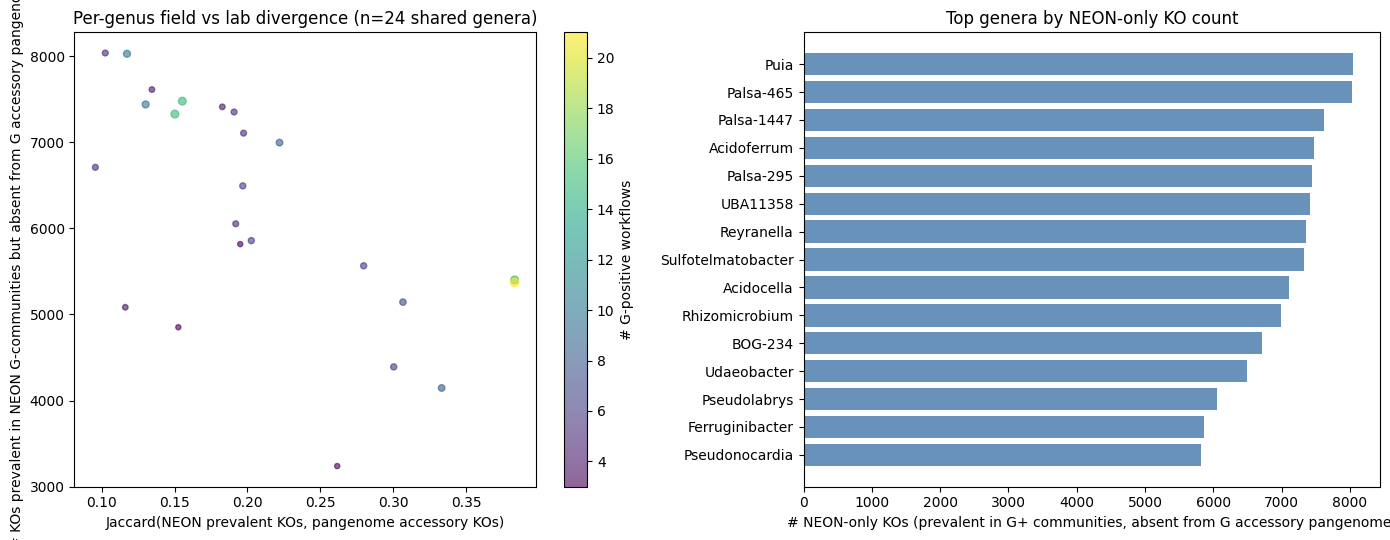

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
ax = axes[0]
sc = ax.scatter(contrast.jaccard_prevalent, contrast.n_neon_only_prevalent,
                s=np.sqrt(contrast.n_pos_workflows) * 8, alpha=0.6, c=contrast.n_pos_workflows, cmap='viridis')
ax.set_xlabel('Jaccard(NEON prevalent KOs, pangenome accessory KOs)')
ax.set_ylabel('# KOs prevalent in NEON G-communities but absent from G accessory pangenome')
ax.set_title(f'Per-genus field vs lab divergence (n={len(contrast)} shared genera)')
plt.colorbar(sc, ax=ax, label='# G-positive workflows')

ax = axes[1]
top = contrast.head(15)
ax.barh(top.genus[::-1], top.n_neon_only_prevalent[::-1], color='#4477AA', alpha=0.8)
ax.set_xlabel('# NEON-only KOs (prevalent in G+ communities, absent from G accessory pangenome)')
ax.set_title('Top genera by NEON-only KO count')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/04_per_genus_contrast.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. KEGG module enrichment of the pooled NEON-only KOs

Pooling across genera, the question is: across the union of all KOs that are NEON-community-prevalent but absent from any cultured accessory pangenome of the relevant genus, are KEGG modules enriched?

If the answer is yes and the enriched modules are environmental-process functions (metal transport, secondary metabolism, anaerobic respiration), H4 is supported in its biological intent: the field carries gene content the lab does not, and that gene content is biologically coherent with the field. If the enriched modules are housekeeping or look random, H4's *direction* fails even if the *count* of NEON-only KOs is large.

The Fisher test universe is the same prevalence-filtered KO universe from NB03 (≥ 5% workflow prevalence), so the comparison is calibrated to the function space we can actually observe in NEON metagenomes.

In [10]:
# Pooled NEON-only KO set across all analyzed genera
pooled_neon_only = set()
for genus in contrast.genus:
    pos_wfs = [w for w,gs in wf_genera.items() if genus in gs and w in MB.index]
    if len(pos_wfs) < 3: continue
    sub = MB.loc[pos_wfs]
    neon_prevalent = set(sub.columns[sub.sum(axis=0) >= (len(pos_wfs) / 2)])
    pg = acc_by_genus.get(genus, set())
    pooled_neon_only |= (neon_prevalent - pg)
print(f'pooled NEON-only KOs (any genus): {len(pooled_neon_only)}')

# Universe = KOs in our prevalence-filtered matrix
universe = set(M.columns)
ko_module = spark.sql("SELECT replace(ko_id,'ko:','') AS ko_id, module_id FROM nmdc_arkin.kegg_ko_module").toPandas()
ko_module_u = ko_module[ko_module.ko_id.isin(universe)]
print(f'universe KOs mapped to any KEGG module: {ko_module_u.ko_id.nunique()} / {len(universe)}')

pooled NEON-only KOs (any genus): 9547


universe KOs mapped to any KEGG module: 1644 / 9584


In [11]:
rows = []
neon_only_u = pooled_neon_only & universe
for mod, sub in ko_module_u.groupby('module_id'):
    mod_kos = set(sub.ko_id)
    a = len(neon_only_u & mod_kos)
    b = len(neon_only_u - mod_kos)
    c = len(mod_kos - neon_only_u)
    d = len(universe - neon_only_u - mod_kos)
    if a == 0 or a + c < 3: continue
    odds, p = stats.fisher_exact([[a, b], [c, d]], alternative='greater')
    rows.append({'module_id': mod, 'k_in_neon_only': a, 'k_total_in_module': a+c,
                 'fold_enrichment': (a/max(a+b,1)) / max(((a+c)/(a+b+c+d)), 1e-9),
                 'p': p})
mod_enr = pd.DataFrame(rows)
if len(mod_enr):
    mod_enr['fdr_q'] = multipletests(mod_enr.p, method='fdr_bh')[1]
    mod_enr = mod_enr.sort_values(['fdr_q','fold_enrichment'], ascending=[True, False])
    mod_enr.to_csv(f'{DATA_DIR}/04_neon_only_module_enrichment.tsv', sep='\t', index=False)
    sig = mod_enr[mod_enr.fdr_q < 0.05]
    print(f'{len(sig)} modules enriched in pooled NEON-only KOs at FDR < 0.05')
    print(sig.head(20).to_string(index=False))
else:
    print('no module enrichment computed')

0 modules enriched in pooled NEON-only KOs at FDR < 0.05
Empty DataFrame
Columns: [module_id, k_in_neon_only, k_total_in_module, fold_enrichment, p, fdr_q]
Index: []


In [12]:
if len(mod_enr):
    sig = mod_enr[mod_enr.fdr_q < 0.05].head(15)
    if len(sig):
        fig, ax = plt.subplots(figsize=(8, max(3, 0.35*len(sig))))
        ax.barh(sig.module_id[::-1], sig.fold_enrichment[::-1], color='#AA3377', alpha=0.85)
        ax.set_xlabel('fold enrichment')
        ax.set_title('KEGG modules enriched in pooled NEON-only KOs (FDR<0.05)')
        plt.tight_layout()
        plt.savefig(f'{FIG_DIR}/04_neon_only_modules.png', dpi=120, bbox_inches='tight')
        plt.show()
    else:
        print('no significant module enrichment to plot')

no significant module enrichment to plot


## 6. H4 verdict

**Falsification rule** (from the research plan): H0 is *not rejected* (H4 fails) if fewer than 10% of overlapping-genus comparisons show any NEON-only KOs above a per-gene-cluster occurrence threshold.

**Operationalization here**: "any NEON-only KO" = ≥ 1 KO that is prevalent in ≥ 50% of G-positive workflows and absent from the G accessory pangenome. We report the fraction of analyzed genera that meet this, plus the module-level direction check.

In [13]:
frac_with_neon_only = (contrast.n_neon_only_prevalent > 0).mean()
median_neon_only = contrast.n_neon_only_prevalent.median()
median_jaccard = contrast.jaccard_prevalent.median()
print('H4 — environmental MAG communities carry KOs absent from cultured G accessory pangenomes?')
print(f'  genera analyzed: {len(contrast)}')
print(f'  fraction with ≥1 NEON-only prevalent KO: {frac_with_neon_only:.2%}')
print(f'  median NEON-only KO count per genus: {median_neon_only:.0f}')
print(f'  median Jaccard(NEON, pangenome accessory): {median_jaccard:.3f}')
h4_count_pass = frac_with_neon_only >= 0.10
h4_direction_pass = bool(len(mod_enr) and (mod_enr.fdr_q < 0.05).any()) if 'mod_enr' in dir() else False
print(f'  H4 count criterion (≥10% of genera have NEON-only KOs): {h4_count_pass}')
print(f'  H4 direction criterion (≥1 KEGG module enriched in pooled NEON-only KOs): {h4_direction_pass}')
print(f'  H4 supported (both criteria): {h4_count_pass and h4_direction_pass}')

H4 — environmental MAG communities carry KOs absent from cultured G accessory pangenomes?
  genera analyzed: 24
  fraction with ≥1 NEON-only prevalent KO: 100.00%
  median NEON-only KO count per genus: 6275
  median Jaccard(NEON, pangenome accessory): 0.194
  H4 count criterion (≥10% of genera have NEON-only KOs): True
  H4 direction criterion (≥1 KEGG module enriched in pooled NEON-only KOs): False
  H4 supported (both criteria): False
